# REDES NEURONALES CONVOLUCIONALES

## Tensores
- Dato multidimensional (escalar, vector, matriz, tensor)

<img src="img/tensors.jpeg" width="600">

<img src="./img/3d_tensor.PNG" width="700">

- Deep learning consiste en una serie de transformaciones (operaciones matemáticas con tensores) del input para dar output. 

<img src="./img/sheet_transformacion.PNG" width="400">

 - Operacion mas importante: tensor dot (matmul)

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

modelo = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(256,)), # input 2D tensor con dimensiones 256,ANY. La sintaxis (256,) indica tuple con solo un numero
    tf.keras.layers.Dense(64, ),  # output 1D tensor con dimensiones (64)
    tf.keras.layers.Dense(32, )   # (input asumido de la capa anterior) output 1D tensor con dimension (32)
])

In [5]:
# mostrar estructura del modelo
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,528 (72.38 KB)

 Trainable params: 18,528 (72.38 KB)

 Non-trainable params: 0 (0.00 B)

# CONSTRUCCIÓN DE REDES

Para la construcción de nuestras arquitecturas tenemos que tener en cuenta que exista compatibilidad entre las dimensiones de output e input entre las capas !!!

## Tipos de capas
- Cada tipo de capa suele tener un uso (dependiente de la red a diseñar según el tipo de entrada y la aplicación):
 - **Dense** para tratar input vector o **datos estructurados** (2D tensor de samples,features)
 - **LSTM** (Recurrent Neural Networks) para tratar **secuencias lógicas** (3D tensores de samples,timestep,features)
 - **Convolucionales** (Convolutional Neural Network) para tratar **imagenes** (4D tensores de samples,height,weight,channels)


## Estructura de la red neuronal
- La mas habitual es secuencial (feedforward), pero hay más
    - Two-branch, 
    - Multihead, 
    - Inception
- La arquitectura ideal es un arte: Documentación tipo de problema, experiencia, experimentación.

## Convolución   

Una **convolución** es una operación matemática que refiere a la aplicación de una *función de ventana deslizante* a una matriz de píxeles que representa una imagen.    
La función de deslizamiento aplicada a la matriz se denomina **kernel**, núcleo o filtro, utilizados indistintamente.   

Las redes neuronales convolucionales se inspiraron en la arquitectura en capas de la corteza visual humana, y a continuación se exponen algunas similitudes y diferencias clave:   

- Arquitectura jerárquica: Tanto las CNN como la corteza visual tienen una estructura jerárquica, con las características sencillas extraídas en las capas tempranas y las características más complejas construidas en capas más profundas. Esto permite representaciones cada vez más sofisticadas de las entradas visuales.
- Conectividad local: Las neuronas de la corteza visual solo se conectan a una región local de la entrada, no a todo el campo visual. Del mismo modo, las neuronas de una capa CNN solo están conectadas a una región local del volumen de entrada mediante la operación de convolución. Esta conectividad local permite la eficiencia.
- Invariabilidad traslacional: Las neuronas de la corteza visual pueden detectar características independientemente de su ubicación en el campo visual. Las capas de agrupamiento de una CNN proporcionan cierto grado de invariabilidad traslacional resumiendo las características locales.
- Varios mapas de características: En cada fase del procesamiento visual, se extraen muchos mapas de características diferentes. Las CNN imitan esto mediante varias mapas de filtros en cada capa de convolución.
- No linealidad: Las neuronas de la corteza visual presentan propiedades de respuesta no lineales. Las CNN consiguen la no linealidad mediante funciones de activación como ReLU aplicadas después de cada convolución.    


<img src="./img/cnn_img.avif" width="850">   


Las CNN imitan el sistema visual humano, pero son más sencillas, ya que carecen de sus complejos mecanismos de retroalimentación y se basan en el aprendizaje supervisado en lugar de en el no supervisado, lo que impulsa los avances en la visión artificial a pesar de estas diferencias.

- Las capas densas (*Dense layers*) son las que aprenden patrones globales (en toda la imagen) 
- Las capas con *Convoluciones* (*Conv2D*) detectan patrones locales y, además, son resistentes a transformaciones geométricas.

Las convoluciones permiten aprender jerarquías de patrones (patrones locales como lineas, curvas, etc. a circulos, rectangulos, a constelaciones)

<img src="img/cnn_representations.jpg" width="700">


## ¿Cómo funcionan?

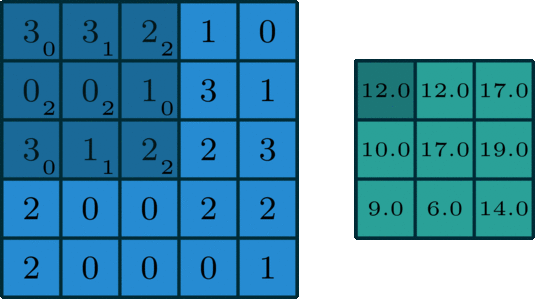

In [6]:
from IPython.display import Image
Image(filename="img/conv_normal.gif")

- Divide el input (3D tensor) en parches y aplica la operación convolución (la misma en cada capa) a cada parche

- Output (3D tensor) es un mapa de features o **mapa de activaciones** (cada una el resultado de aplicar la transformacion). Dicho mapa tendra dimensiones **Height x Width x Nº filtros**. Cada capa del volumen (eje z) es el resultado de aplicar un filtro a cada parche del input.

- La convolución desliza cada parche sobre el input, parando en cada posible posicion y aplicando la transformacion (función kernel)

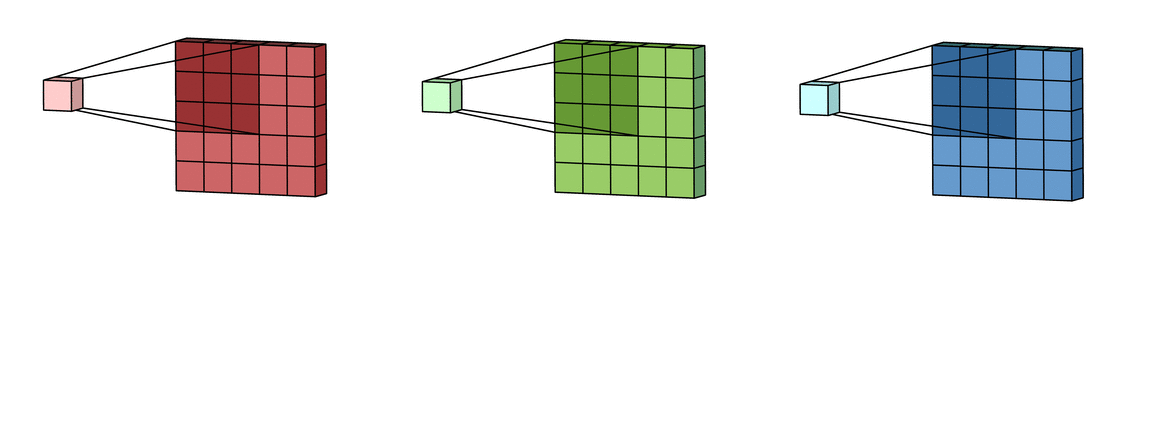

In [11]:
Image(filename="img/conv_multichannel.gif")

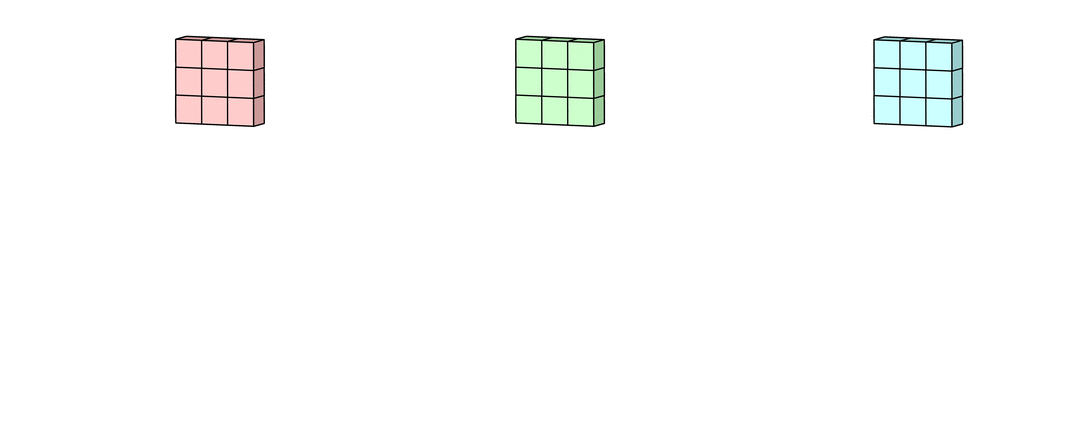

In [12]:
Image(filename="img/conv_multichannel_2.gif")

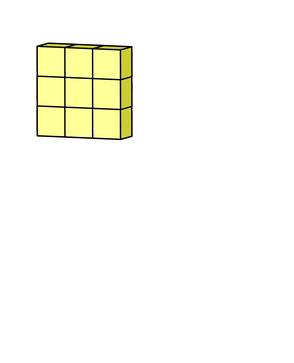

In [13]:
Image(filename="img/bias_cnn.gif")

### Padding 
- Sólo hay 9 formas de aplicar un parche 3x3 a un imagen de 5x5.
- Si se quiere aplicar a todos los pixeles --> **padding** (añadir filas y columnas para hacerlo posible)

Así, el **padding** consiste simplemente en agregar pixeles con valor igual a cero a los bordes de la imagen original, tal y cómo se muestra en la siguiente imagen.

```python
Conv2D(...,padding=<valor>): 'valid' sin padding, 'same' para igualar tamaño input y output feature 
```

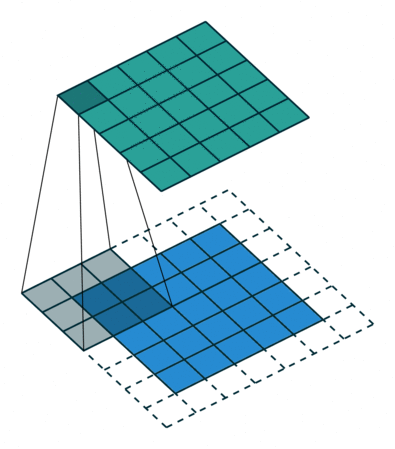

In [14]:
Image(filename="img/conv_padding.gif")

### Striding ##

En la convolución original, el kernel se desplaza un pixel hacia la derecha, o hacia abajo, durante cada iteración. Cada uno de estos desplazamientos se conoce como stride (o salto), y en la convolución original este valor es igual a 1, aunque también es posible realizar la convolución con strides mayores, lo que permite obtener imágenes resultantes de menor tamaño en comparación con las obtenidas en la convolución original

- El **Stride**, por tanto, determina el salto entre ventana y ventana

```python
Conv2D(...,stride=<valor>): int, salto entre ventanas 
```

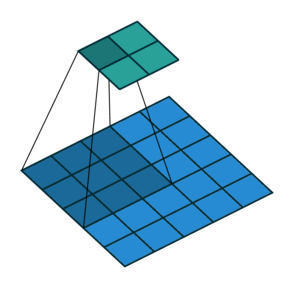

In [15]:
Image(filename="img/conv_stride.gif")

### Pooling (agrupamiento)  

El objetivo de la capa de agrupamiento es el traer las características más significativas de la matriz convolucionada. Esto se hace aplicando algunas operaciones de agregación, que reducen la dimensión del mapa de características (matriz convolucionada), reduciendo así la memoria utilizada durante el entrenamiento de la red. El agrupamiento también es relevante para mitigar el sobreajuste.   
Por tanto:
- Se usan para hacer **downsampling del input feature (conjunto inicial de entrada)** (reducir dimensionalidad espacial)
- Similar a convoluciones, pero no aplican un kernel sino que aplican **funcion 'max' (o average)**
- Por defecto, tamaño 2x2 y stride 2.   

Las funciones de agregación más comunes que pueden aplicarse son:

- **Max-pooling**, que es el valor máximo del mapa de características
- El **sum-pooling** es la suma de todos los valores del mapa de características
- El **average-pooling** es la media de todos los valores.   

<img src="./img/pooling.avif" width="600">

In [16]:
# red sin pooling

from tensorflow.keras import models
from tensorflow.keras import layers

convnet_nopooling = models.Sequential()
convnet_nopooling.add(layers.Conv2D(32,(3,3),input_shape=(32,32,3),activation='relu'))
convnet_nopooling.add(layers.Conv2D(32,(3,3),activation='relu'))
convnet_nopooling.add(layers.Conv2D(64,(3,3),activation='relu'))
convnet_nopooling.add(layers.Conv2D(64,(3,3),activation='relu'))
convnet_nopooling.add(layers.Flatten())
convnet_nopooling.add(layers.Dense(512,activation='relu'))
convnet_nopooling.add(layers.Dense(10,activation='softmax'))

convnet_nopooling.summary()

e:\Users\Jordi\anaconda3\envs\ceiadb\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,945,578 (72.27 MB)

 Trainable params: 18,945,578 (72.27 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Red con pooling
convnet_pooling = models.Sequential()

########################## BASE MODEL ###### ENCARGADO DE EXTRAER CARACTERÍSTICAS AUTOMÁTICAMENTE
#BLOQUE CONVOLUCIONAL 1
convnet_pooling.add(layers.Conv2D(32,(3,3),input_shape=(32,32,3),activation='relu'))
convnet_pooling.add(layers.Conv2D(32,(3,3),activation='relu'))
convnet_pooling.add(layers.MaxPooling2D((2,2)))

#BLOQUE CONVOLUCIONAL 2
convnet_pooling.add(layers.Conv2D(64,(3,3),activation='relu'))
convnet_pooling.add(layers.Conv2D(64,(3,3),activation='relu'))
convnet_pooling.add(layers.MaxPooling2D((2,2)))

########################## TOP MODEL ###### ENCARGADO LLEVAR A CABO LA CLASIFICACIÓN
convnet_pooling.add(layers.Flatten())
convnet_pooling.add(layers.Dense(512,activation='relu'))
convnet_pooling.add(layers.Dense(10,activation='softmax'))

convnet_pooling.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,410 (3.40 MB)

 Trainable params: 890,410 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

# EJEMPLO PRÁCTICO
## MODELO RED NEURONAL CONVOLUCIONAL

Usaremos el dataset de imágenes de flores ("flowers") que dispone de 5 clases distintas de flores y que forma parte de los datasets de tensorflow.

Previamente haremos un preprocesamiento para estandarizar todas las imágenes en un tamaño único. De igual modo, las imágenes tienen tres canales de color (rojo, verde y azul).

### 1. IMPORTAMOS LIBRERÍAS

In [1]:
# IMPORTAMOS LIBRERIAS
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import cv2
import numpy as np

### 2. DESCARGAMOS DATASET "Flowers"

Los parámetros *as_supervised*, *with_info* descargan información y metadatos adicionales retornando dos valores que se almacenan en las variables datos y metadatos:

In [2]:
datos, metadatos = tfds.load("tf_flowers", as_supervised=True, with_info=True)

### 3. ANÁLISIS DEL DATASET

Se puede observar lo siguiente:

- Las imágenes tienen diferentes tamaños.
- Tienen tres canales de color (son imágenes a color).

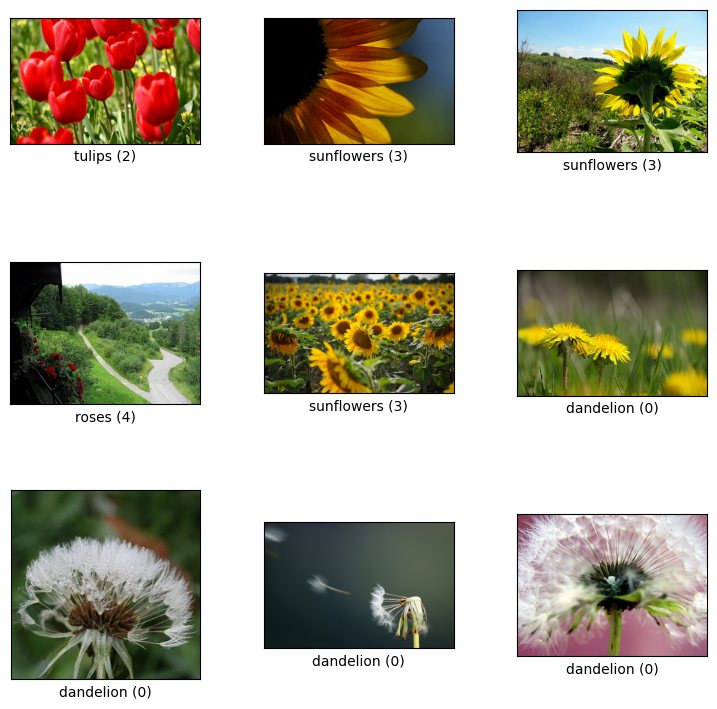

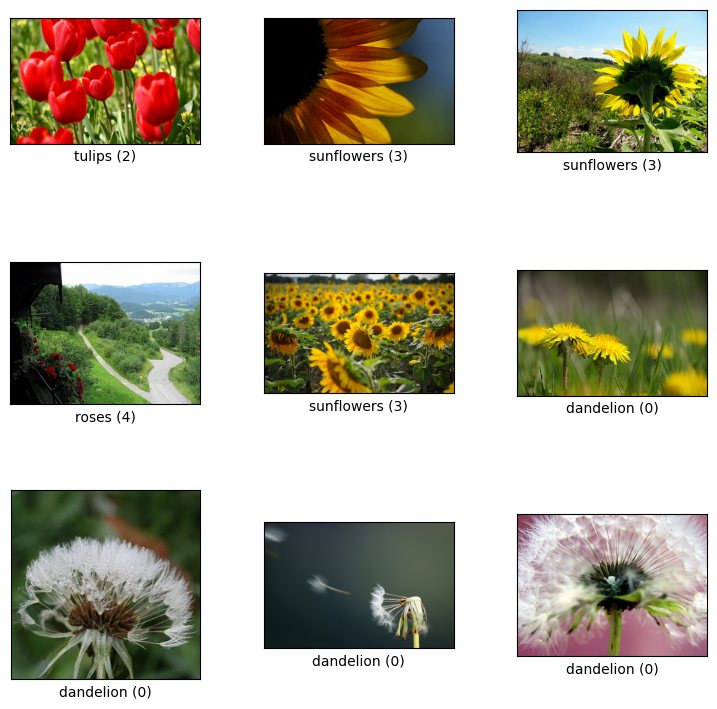

In [3]:
tfds.show_examples(datos["train"], metadatos)

### 4. PREPROCESADO DE DATOS (SOBRE UNA MUESTRA REDUCIDA)

A modo de ejemplo se realiza el preprocesado de solo 20 imágenes. En base a lo visto en el paso 3, haremos los siguiente:

- Se redimensionan las imágenes a 100x100 px, reduciendo e igualando su tamaño (así se disminuye el número de neuronas en la capa de entrada y el tiempo de entrenamiento).
- Pasaremos de color a imágenes en escala de grises (se reduce así el procesamiento).

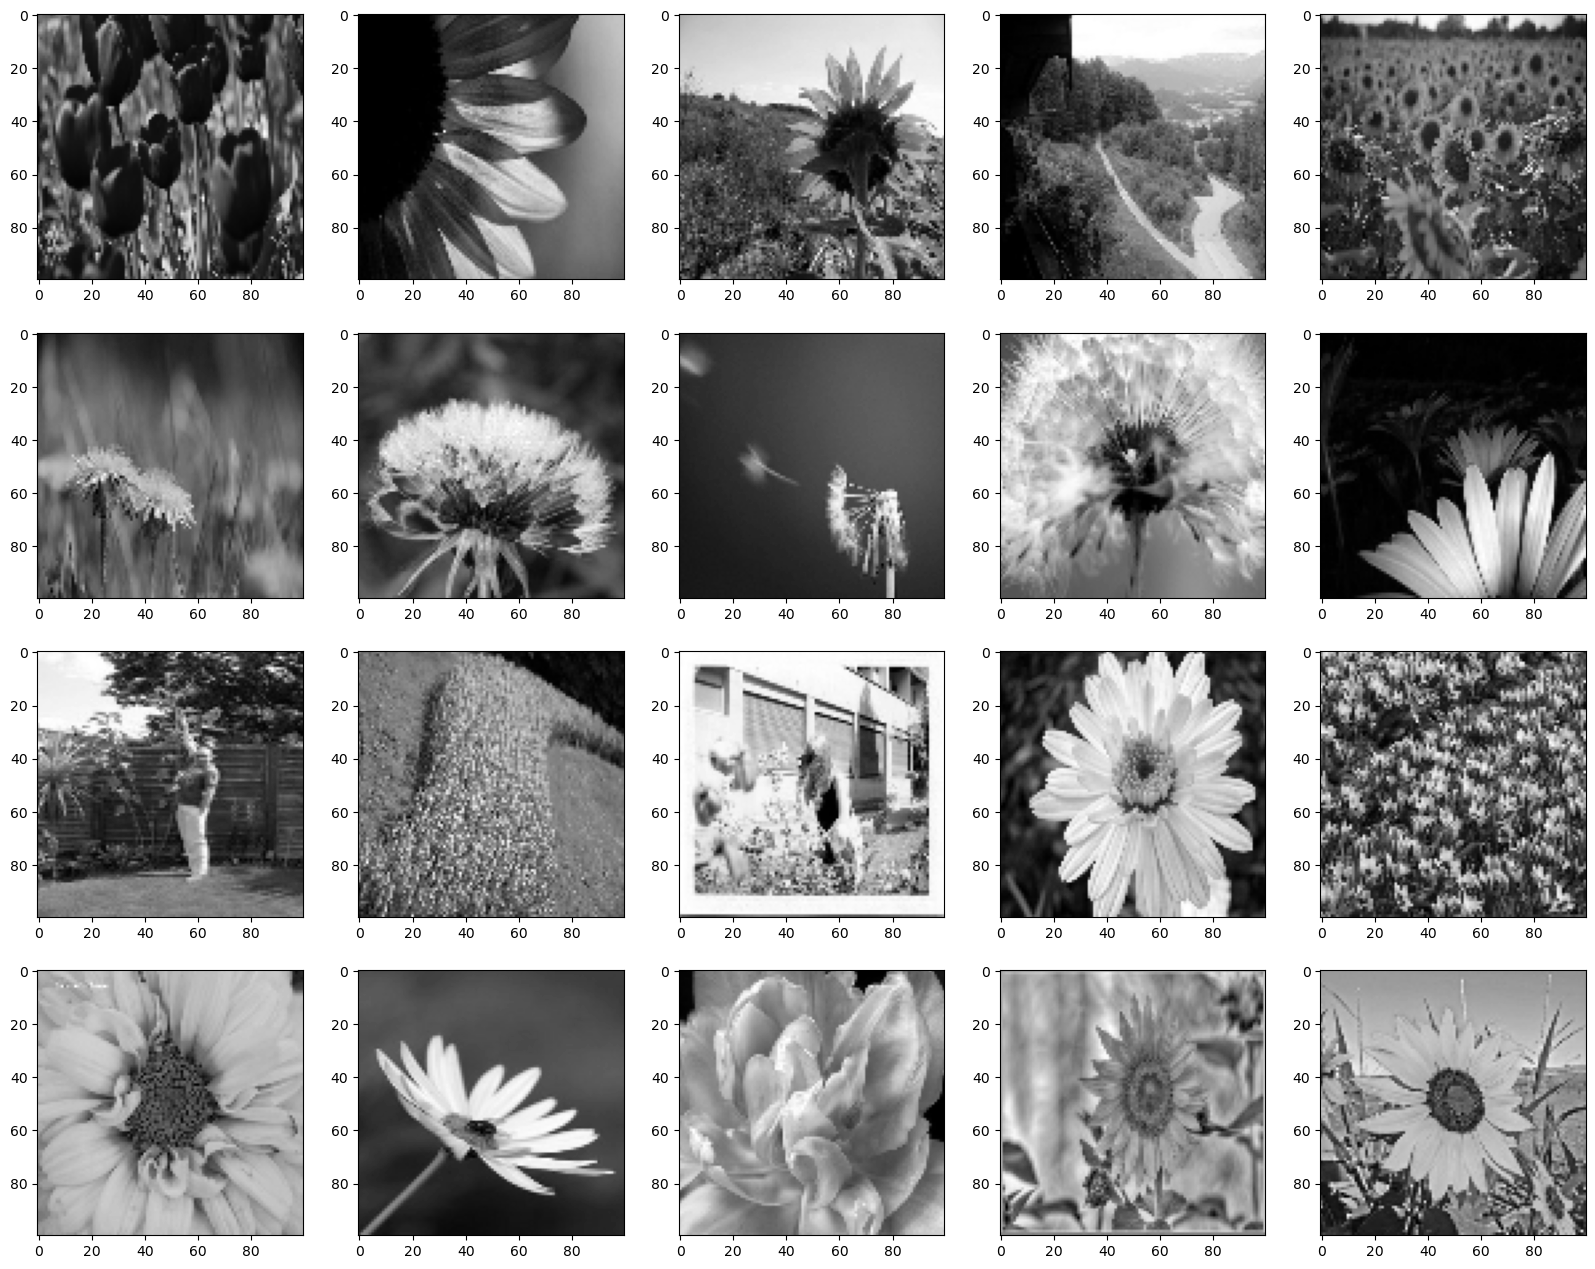

In [4]:
plt.figure(figsize=(20,20))

TAMANO_IMG=100

# redimensionamos solo a 20 imágenes
for i, (imagen, etiqueta) in enumerate(datos["train"].take(20)):
  # a. Redimensionamos las imágenes a 100x100 píxeles:
  imagen = cv2.resize(imagen.numpy(), (TAMANO_IMG, TAMANO_IMG))
  # b. Pasamos de color a escala de grises:
  imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
  plt.subplot(5, 5, i+1)
  plt.imshow(imagen, cmap="gray")

Comprobamos el número de clases que tiene el dataset

In [5]:
num_classes = metadatos.features['label'].num_classes
print(num_classes)

5


Creamos una lista el cual almacenará todo el conjunto de imágenes.

In [6]:
datos_entrenamiento = []

### 5. PREPROCESADO DE TODAS LAS IMÁGENES

In [7]:
for i, (imagen, etiqueta) in enumerate(datos["train"]):
  imagen = cv2.resize(imagen.numpy(), (TAMANO_IMG, TAMANO_IMG))
  imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
  imagen = imagen.reshape(TAMANO_IMG, TAMANO_IMG, 1) # 1 canal de color.

  # datos_entrenamiento: lista que almacenará listas de dos posiciones (los pixeles
  # de la imágen y su etiqueta)
  datos_entrenamiento.append([imagen, etiqueta])

In [8]:
#datos_entrenamiento ahora contiene las 3670 imágenes preprocesadas
len(datos_entrenamiento)

3670

### 6. SEPARACIÓN DE CONJUNTOS DE ENTRENAMIENTO

In [9]:
X = []
y = []

# Iteramos todos los datos de entrenamiento y lo agregamos en X (imagen), y (etiqueta):
for imagen, etiqueta in datos_entrenamiento:
  X.append(imagen)
  y.append(etiqueta)

### 7. NORMALIZACIÓN DE IMÁGENES

Se divide cada píxel entre 255, para discretizar los valores de cada píxel dentro del rango [0, 1]

In [10]:
X = np.array(X).astype(float) / 255

# Pasamos a "y" en un arreglo de numpay
y = np.array(y)

### 8. DISEÑO ARQUITECTURA MODELO RED NEURONAL CONVOLUCIONAL - CNN

Se mezclan las capas convolucionales, densas y de aplanado/agrupación, así como las de *pooling* que aportan reducción de dimensionalidad

In [11]:
modelo = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(100, 100, 1)),
    tf.keras.layers.Conv2D(16, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes)
])

Dado que se trata de una clasificación multiclase, usamos como función de pérdida la **SparseCategoricalCrossentropy** y el optimizador **Adam**

In [12]:
modelo.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), #usamos esta pérdida porque es multiclase
    metrics=["accuracy"]
)

Pasamos a entrenar el modelo. Dentro de los parámetros que se pueden definir en este paso, está el que hace referencia al número de muestra/elementos que son evaluadas antes de que los pesos sean actualizados en la red neuronal y que se denomina *batch_size*. Si este parámetro tiene un valor pequeño, se provoca que la red tenga poca cantidad de datos en memoria y, en teoría, su entrenamiento sea más rápido.

In [13]:
train_log = modelo.fit(
    X, y, batch_size=32,
    validation_split=0.20,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.2744 - loss: 1.5635 - val_accuracy: 0.4360 - val_loss: 1.3720
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4525 - loss: 1.3444 - val_accuracy: 0.4441 - val_loss: 1.3089
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4880 - loss: 1.2419 - val_accuracy: 0.4837 - val_loss: 1.2521
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5357 - loss: 1.1679 - val_accuracy: 0.5218 - val_loss: 1.1801
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6167 - loss: 1.0045 - val_accuracy: 0.5300 - val_loss: 1.1700
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6447 - loss: 0.9050 - val_accuracy: 0.5422 - val_loss: 1.1483
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7277 - loss: 0.7287 - val_accuracy: 0.5245 - val_loss: 1.2497
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8039 - loss: 0.5631 - val_accuracy: 0.5531 - v

Por último, evaluamos el modelo para comprobar su eficiencia

In [14]:
modelo.evaluate(X, y, batch_size=32)

115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9877 - loss: 0.0801


[0.5298988223075867, 0.9103541970252991]

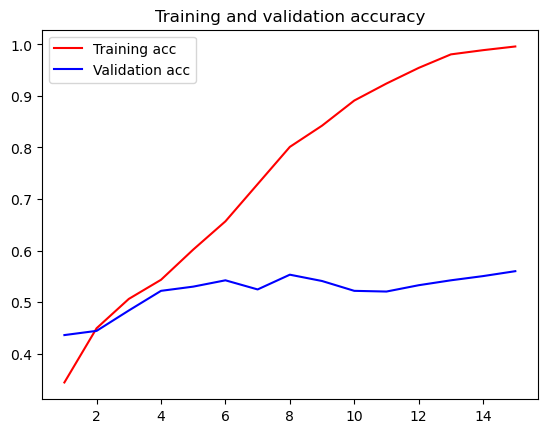

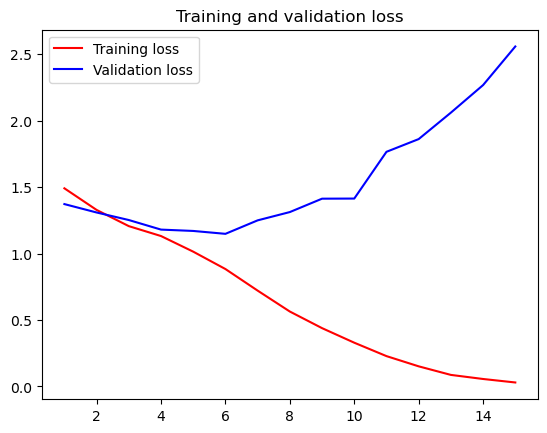

In [17]:
import matplotlib.pyplot as plt
 
acc = train_log.history['accuracy']
val_acc = train_log.history['val_accuracy']
loss = train_log.history['loss']
val_loss = train_log.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

En la segunda gráfica observamos que hay un problema. La red neuronal comienza a tener problemas con el conjunto de validación y se observa como la función de coste crece en vez de minimizarse. Es un claro problema de overfitting. 
Vamos a recurrir a una técnica habitual en estos casos, que consiste en eliminar complejidad de la red. Al disminuir esta, conseguimos que se simplifique el modelo y que logre generalizar mejor. 
Una forma de reducir esta complejidad es eliminar algunas conexiones de forma aleatoria entre dos capas. Esto se puede hacer con una capa *Dropout()*. Como parámetro se pasa el porcentaje de conexiones que se desea anular (por ejemplo un valor de 0.25 eliminará el 25% de las conexiones).

In [18]:
modelo = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(shape=(100, 100, 1)),
    tf.keras.layers.Conv2D(16, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Dropout(0.25),
    
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dropout(0.25),
    
    tf.keras.layers.Dense(num_classes)
])

In [19]:
modelo.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), #usamos esta pérdida porque es multiclase
    metrics=["accuracy"]
)

In [20]:
train_log = modelo.fit(
    X, y, batch_size=32,
    validation_split=0.20,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.2668 - loss: 1.6036 - val_accuracy: 0.3161 - val_loss: 1.5227
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.3541 - loss: 1.4916 - val_accuracy: 0.3460 - val_loss: 1.4911
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4150 - loss: 1.4040 - val_accuracy: 0.3883 - val_loss: 1.3847
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4497 - loss: 1.3194 - val_accuracy: 0.4101 - val_loss: 1.3781
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.4872 - loss: 1.2483 - val_accuracy: 0.4578 - val_loss: 1.3031
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5187 - loss: 1.1766 - val_accuracy: 0.4768 - val_loss: 1.2617
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5607 - loss: 1.0917 - val_accuracy: 0.5368 - val_loss: 1.1581
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6077 - loss: 1.0063 - val_accuracy: 0.5245 - v

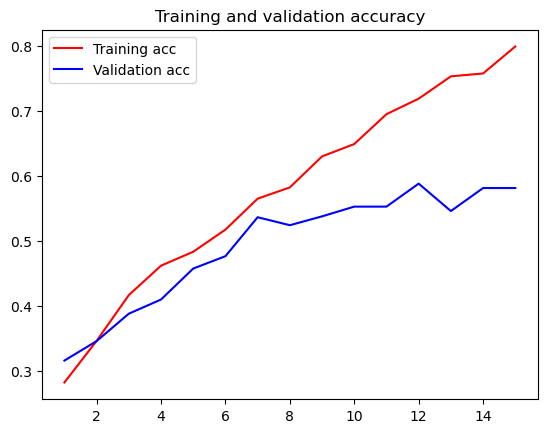

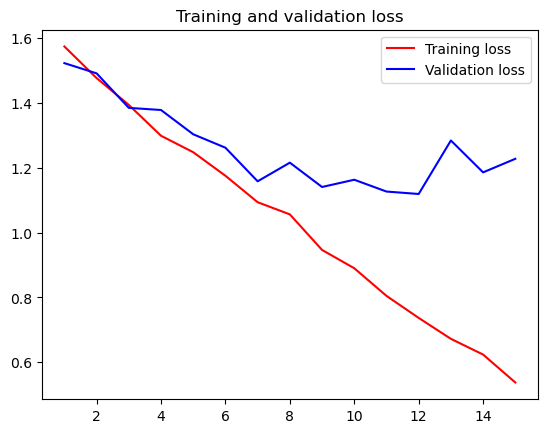

In [21]:
acc = train_log.history['accuracy']
val_acc = train_log.history['val_accuracy']
loss = train_log.history['loss']
val_loss = train_log.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Como vemos, ahora la cosa está algo mejor, aunque sigue sin conseguir afinarse del todo. 
Puede observarse que el proceso de ajuste de este tipo de modelos requiere grandes dosis de paciencia y de repetición del experimento.